# Capítulo 1. Selección y exploración de los datos de estratificación socioeconómica

## Metodología SEMMA: Sample y Explore

Este notebook desarrolla las fases **Sample** y **Explore** de la metodología SEMMA aplicadas al análisis de datos de estratificación socioeconómica en Colombia.

### Objetivos del capítulo
- Seleccionar y consolidar el conjunto de datos.
- Identificar las variables relevantes para el análisis.
- Explorar la distribución de estratos socioeconómicos.
- Evaluar la calidad de los datos.
- Generar estadísticas descriptivas iniciales.


# 1.1 Contexto y delimitación del estudio

La estratificación socioeconómica en Colombia permite clasificar las viviendas según sus características físicas y condiciones del entorno. Este análisis busca explorar patrones asociados a las edificaciones y su relación con los estratos socioeconómicos.

El estudio utiliza información catastral relacionada con:
- Departamento
- Área
- Perímetro
- Número de pisos
- Tipo de dominio
- Tipo de construcción
- Estrato socioeconómico

La muestra trabajada corresponde a 50.000 registros seleccionados para análisis descriptivo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# 1.2 Fuentes de información y selección del conjunto de datos

Los datos utilizados provienen de:
- Información catastral pública
- Dataset de estratificación socioeconómica
- Tabla de departamentos de Colombia DIAN

Durante el proceso se realizó:
- Integración de datasets
- Limpieza de variables
- Renombramiento de columnas
- Selección de variables relevantes
- Exportación del dataset procesado


## Proceso de consolidación e integración de datos

Para la construcción del dataset analítico se realizó un proceso de integración de diferentes fuentes de información territorial y catastral.

El proceso incluyó:
- Carga de datasets originales.
- Validación de estructuras y tipos de datos.
- Relación de registros mediante códigos departamentales.
- Selección de variables relevantes para el análisis socioeconómico.
- Estandarización de nombres y formatos de variables.
- Consolidación de la información en un único dataset procesado.

Este proceso permitió transformar datos provenientes de múltiples fuentes en una estructura analítica adecuada para las fases posteriores de la metodología SEMMA.

In [2]:
df_catastro = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\raw\dataset-CATASTRO-PUBLICO.csv',
    encoding='latin1',
    sep=';'
)

In [3]:
df_catastro.head()

,OBJECTID,Codigo,Terreno_Codigo,Tipo_Construccion,Tipo_Dominio,Numero_Pisos,Numero_Sotanos,Numero_Mezanines,Numero_Semisotanos,Etiqueta,Identificador,Codigo_Edificacion,Codigo_Anterior,GLOBALID,Shape__Area,Shape__Length,codigo_departamento
0,1,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,2,0,0,0,0,A-B,1.0,"1,58E+19",674a4ff4-a739-45bf-90aa-6a3b61325d1e,"28,21337891","22,14964995",20
1,2,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",3699a453-0d30-4714-bdd9-d64cd9af9d25,"148,7758789","52,84152652",91
2,3,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",c77418cb-e59e-4efd-8b62-f923edb2128f,"108,3251953","43,20766152",15
3,4,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,B,1.0,"1,58E+19",baec0ce2-ead0-4a0f-a6d5-50b30a2293cf,"63,10009766","51,7578177",91
4,5,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,3,0,0,0,0,A-B,1.0,"1,58E+19",aa330797-5886-45c0-9cc9-2195642ba157,"54,9296875","29,6990689",73


In [4]:
df_catastro.columns

Index(['OBJECTID', 'Codigo', 'Terreno_Codigo', 'Tipo_Construccion',
       'Tipo_Dominio', 'Numero_Pisos', 'Numero_Sotanos', 'Numero_Mezanines',
       'Numero_Semisotanos', 'Etiqueta', 'Identificador', 'Codigo_Edificacion',
       'Codigo_Anterior', 'GLOBALID', 'Shape__Area', 'Shape__Length',
       'codigo_departamento'],
      dtype='object')

In [5]:
df_departamentos = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\raw\departamentos_colombia.csv',
    encoding='latin1',
    sep=';'
)

In [6]:
df_departamentos.head()

,Departamento,Código
0,Amazonas,91
1,Antioquia,5
2,Arauca,81
3,Atlántico,8
4,Bolívar,13


In [7]:
df_departamentos.rename(
    columns={
        'Código': 'codigo_departamento',
        'Departamento': 'departamento'
    },
    inplace=True
)

In [8]:
df_departamentos.columns

Index(['departamento', 'codigo_departamento'], dtype='object')

In [9]:
df_departamentos.head()

,departamento,codigo_departamento
0,Amazonas,91
1,Antioquia,5
2,Arauca,81
3,Atlántico,8
4,Bolívar,13


In [10]:
df_catastro['codigo_departamento'].dtype

dtype('int64')

In [11]:
df_departamentos['codigo_departamento'].dtype

dtype('int64')

In [12]:
df_test = pd.merge(
    df_catastro,
    df_departamentos,
    on='codigo_departamento',
    how='left'
)

df_test.head()

,OBJECTID,Codigo,Terreno_Codigo,Tipo_Construccion,Tipo_Dominio,Numero_Pisos,Numero_Sotanos,Numero_Mezanines,Numero_Semisotanos,Etiqueta,Identificador,Codigo_Edificacion,Codigo_Anterior,GLOBALID,Shape__Area,Shape__Length,codigo_departamento,departamento
0,1,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,2,0,0,0,0,A-B,1.0,"1,58E+19",674a4ff4-a739-45bf-90aa-6a3b61325d1e,"28,21337891","22,14964995",20,Cesar
1,2,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",3699a453-0d30-4714-bdd9-d64cd9af9d25,"148,7758789","52,84152652",91,Amazonas
2,3,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",c77418cb-e59e-4efd-8b62-f923edb2128f,"108,3251953","43,20766152",15,Boyacá
3,4,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,B,1.0,"1,58E+19",baec0ce2-ead0-4a0f-a6d5-50b30a2293cf,"63,10009766","51,7578177",91,Amazonas
4,5,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,3,0,0,0,0,A-B,1.0,"1,58E+19",aa330797-5886-45c0-9cc9-2195642ba157,"54,9296875","29,6990689",73,Tolima


In [ ]:
# Validación de registros sin departamento asociado

df_test['departamento'].isnull().sum()

In [ ]:
# Cobertura territorial del dataset

df_test['departamento'].nunique()

In [ ]:
# Dimensiones del dataset consolidado

print("Dimensiones dataset integrado:")
print(df_test.shape)

(50000, 18)

In [14]:
df_test.head()

,OBJECTID,Codigo,Terreno_Codigo,Tipo_Construccion,Tipo_Dominio,Numero_Pisos,Numero_Sotanos,Numero_Mezanines,Numero_Semisotanos,Etiqueta,Identificador,Codigo_Edificacion,Codigo_Anterior,GLOBALID,Shape__Area,Shape__Length,codigo_departamento,departamento
0,1,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,2,0,0,0,0,A-B,1.0,"1,58E+19",674a4ff4-a739-45bf-90aa-6a3b61325d1e,"28,21337891","22,14964995",20,Cesar
1,2,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",3699a453-0d30-4714-bdd9-d64cd9af9d25,"148,7758789","52,84152652",91,Amazonas
2,3,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,A,1.0,"1,58E+19",c77418cb-e59e-4efd-8b62-f923edb2128f,"108,3251953","43,20766152",15,Boyacá
3,4,"1,58E+29",NaN,CONVENCIONAL,PRIVADO,1,0,0,0,0,B,1.0,"1,58E+19",baec0ce2-ead0-4a0f-a6d5-50b30a2293cf,"63,10009766","51,7578177",91,Amazonas
4,5,"1,58E+29","1,58E+29",CONVENCIONAL,PRIVADO,3,0,0,0,0,A-B,1.0,"1,58E+19",aa330797-5886-45c0-9cc9-2195642ba157,"54,9296875","29,6990689",73,Tolima


In [15]:
df_modelo = df_test[
    [
        'departamento',
        'codigo_departamento',
        'Numero_Pisos',
        'Shape__Area',
        'Shape__Length',
        'Tipo_Dominio',
        'Tipo_Construccion'
    ]
].copy()

In [16]:
df_modelo.head()

,departamento,codigo_departamento,Numero_Pisos,Shape__Area,Shape__Length,Tipo_Dominio,Tipo_Construccion
0,Cesar,20,2,"28,21337891","22,14964995",PRIVADO,CONVENCIONAL
1,Amazonas,91,1,"148,7758789","52,84152652",PRIVADO,CONVENCIONAL
2,Boyacá,15,1,"108,3251953","43,20766152",PRIVADO,CONVENCIONAL
3,Amazonas,91,1,"63,10009766","51,7578177",PRIVADO,CONVENCIONAL
4,Tolima,73,3,"54,9296875","29,6990689",PRIVADO,CONVENCIONAL


In [ ]:
# Dimensiones del dataset analítico

print("Dimensiones dataset analítico:")
print(df_modelo.shape)

(50000, 7)

In [18]:
df_estrato = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\raw\dataset-estrato.csv',
    encoding='latin1',
    sep=';'
)

In [19]:
df_estrato.head()

,ï»¿ESoCLote,ESoChip,ESoEstrato
0,8528020009,AAA0000AMMS,3
1,8528020009,AAA0000AMNN,3
2,8528020009,AAA0000AMTO,3
3,8528020009,AAA0000AMUZ,3
4,8528020009,AAA0000AMWF,3


In [22]:
df_modelo.rename(
    columns={
        'Numero_Pisos': 'numero_pisos',
        'ESoEstrato': 'estrato'
    },
    inplace=True
)

In [21]:
df_modelo.head()

,departamento,codigo_departamento,numero_pisos,Shape__Area,Shape__Length,Tipo_Dominio,Tipo_Construccion
0,Cesar,20,2,"28,21337891","22,14964995",PRIVADO,CONVENCIONAL
1,Amazonas,91,1,"148,7758789","52,84152652",PRIVADO,CONVENCIONAL
2,Boyacá,15,1,"108,3251953","43,20766152",PRIVADO,CONVENCIONAL
3,Amazonas,91,1,"63,10009766","51,7578177",PRIVADO,CONVENCIONAL
4,Tolima,73,3,"54,9296875","29,6990689",PRIVADO,CONVENCIONAL


In [ ]:
# Dimensiones del dataset analítico

print("Dimensiones dataset analítico:")
print(df_modelo.shape)

(50000, 7)

In [24]:
df_modelo['ESoEstrato'] = df_estrato['ESoEstrato']

In [25]:
df_modelo.rename(
    columns={
        'Numero_Pisos': 'numero_pisos',
        'ESoEstrato': 'estrato',
        'Shape__Area': 'area',
        'Shape__Length': 'perimetro',
        'Tipo_Dominio': 'tipo_dominio',
        'Tipo_Construccion': 'tipo_construccion',
        'ï»¿departamento': 'departamento'
    },
    inplace=True
)

In [26]:
df_modelo.head()

,departamento,codigo_departamento,numero_pisos,area,perimetro,tipo_dominio,tipo_construccion,estrato
0,Cesar,20,2,"28,21337891","22,14964995",PRIVADO,CONVENCIONAL,3
1,Amazonas,91,1,"148,7758789","52,84152652",PRIVADO,CONVENCIONAL,3
2,Boyacá,15,1,"108,3251953","43,20766152",PRIVADO,CONVENCIONAL,3
3,Amazonas,91,1,"63,10009766","51,7578177",PRIVADO,CONVENCIONAL,3
4,Tolima,73,3,"54,9296875","29,6990689",PRIVADO,CONVENCIONAL,3


In [27]:
df_modelo.shape

(50000, 8)

In [28]:

df_modelo.to_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\processed\dataset_procesado.csv',
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

print("Dataset guardado correctamente")

Dataset guardado correctamente


## Generación del dataset procesado

Después del proceso de integración, selección y transformación de variables, se generó un dataset procesado consolidado para el análisis descriptivo territorial.

El dataset final contiene variables numéricas y categóricas asociadas a características físicas, territoriales y socioeconómicas relevantes para el estudio de estratificación en Colombia.

In [29]:
df_procesado = pd.read_csv(
    r'C:\Users\STIVEN\OneDrive\universidad\diplomado\Final\data\processed\dataset_procesado.csv',
    encoding='latin1',
    sep=';'
)

df_procesado.head()

,ï»¿departamento,codigo_departamento,numero_pisos,area,perimetro,tipo_dominio,tipo_construccion,estrato
0,Cesar,20,2,"28,21337891","22,14964995",PRIVADO,CONVENCIONAL,3
1,Amazonas,91,1,"148,7758789","52,84152652",PRIVADO,CONVENCIONAL,3
2,BoyacÃ¡,15,1,"108,3251953","43,20766152",PRIVADO,CONVENCIONAL,3
3,Amazonas,91,1,"63,10009766","51,7578177",PRIVADO,CONVENCIONAL,3
4,Tolima,73,3,"54,9296875","29,6990689",PRIVADO,CONVENCIONAL,3


# 1.3 Identificación de variables de estratificación socioeconómica

Las variables seleccionadas permiten analizar características físicas y territoriales asociadas a la estratificación socioeconómica.


## Perfilamiento inicial del dataset

Se realizó una exploración inicial del dataset con el fin de identificar:
- Estructura de variables.
- Tipos de datos.
- Distribución inicial de registros.
- Variables numéricas y categóricas.
- Posibles inconsistencias.

In [30]:

# Información general del dataset

df_modelo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   departamento         50000 non-null  object
 1   codigo_departamento  50000 non-null  int64 
 2   numero_pisos         50000 non-null  int64 
 3   area                 50000 non-null  object
 4   perimetro            50000 non-null  object
 5   tipo_dominio         48906 non-null  object
 6   tipo_construccion    50000 non-null  object
 7   estrato              50000 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 3.1+ MB


In [31]:

# Estadísticas descriptivas

df_modelo.describe(include='all')


,departamento,codigo_departamento,numero_pisos,area,perimetro,tipo_dominio,tipo_construccion,estrato
count,50000,50000.00000,50000.000000,50000,50000,48906,50000,50000.000000
unique,32,NaN,NaN,39752,48975,2,2,NaN
top,Nariño,NaN,NaN,"60,72460938","33,06736963",PRIVADO,CONVENCIONAL,NaN
freq,1669,NaN,NaN,197,60,48905,40622,NaN
mean,NaN,53.35556,1.020080,NaN,NaN,NaN,NaN,2.157380
std,NaN,30.40426,0.173544,NaN,NaN,NaN,NaN,0.484991
min,NaN,5.00000,0.000000,NaN,NaN,NaN,NaN,1.000000
25%,NaN,20.00000,1.000000,NaN,NaN,NaN,NaN,2.000000
50%,NaN,52.00000,1.000000,NaN,NaN,NaN,NaN,2.000000
75%,NaN,81.00000,1.000000,NaN,NaN,NaN,NaN,2.000000


In [ ]:
# Variables categóricas principales

variables_categoricas = [
    'departamento',
    'tipo_dominio',
    'tipo_construccion'
]

for variable in variables_categoricas:
    
    print(f"\nVariable: {variable}")
    print(df_modelo[variable].value_counts().head())

## Variables utilizadas

| Variable | Tipo | Descripción |
|---|---|---|
| departamento | Categórica | Departamento de ubicación |
| codigo_departamento | Numérica | Código DANE del departamento |
| numero_pisos | Numérica | Cantidad de pisos |
| area | Numérica | Área de la construcción |
| perimetro | Numérica | Perímetro de la construcción |
| tipo_dominio | Categórica | Tipo de dominio del predio |
| tipo_construccion | Categórica | Tipo de construcción |
| estrato | Numérica | Estrato socioeconómico |



# 1.4 Exploración inicial de la distribución de estratos

En esta sección se realiza un análisis exploratorio inicial para identificar patrones generales de distribución y comportamiento de las variables.


In [38]:
# Conversión de columnas numéricas

df_modelo['area'] = (
    df_modelo['area']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_modelo['perimetro'] = (
    df_modelo['perimetro']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

# Convertir a tipo numérico
df_modelo['area'] = pd.to_numeric(df_modelo['area'], errors='coerce')
df_modelo['perimetro'] = pd.to_numeric(df_modelo['perimetro'], errors='coerce')
df_modelo['numero_pisos'] = pd.to_numeric(df_modelo['numero_pisos'], errors='coerce')
df_modelo['estrato'] = pd.to_numeric(df_modelo['estrato'], errors='coerce')

In [32]:

# Distribución de estratos

df_modelo['estrato'].value_counts().sort_index()


estrato
1     2547
2    37050
3    10394
4        6
5        2
6        1
Name: count, dtype: int64

In [ ]:
# Valores únicos de estrato

sorted(df_modelo['estrato'].unique())

In [33]:

# Distribución porcentual de estratos

(df_modelo['estrato'].value_counts(normalize=True) * 100).sort_index()


estrato
1     5.094
2    74.100
3    20.788
4     0.012
5     0.004
6     0.002
Name: proportion, dtype: float64

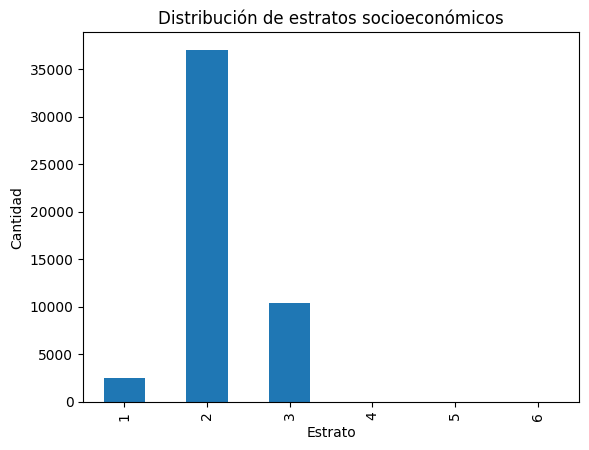

In [34]:

# Visualización de estratos

df_modelo['estrato'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Estrato')
plt.ylabel('Cantidad')
plt.title('Distribución de estratos socioeconómicos')

plt.show()


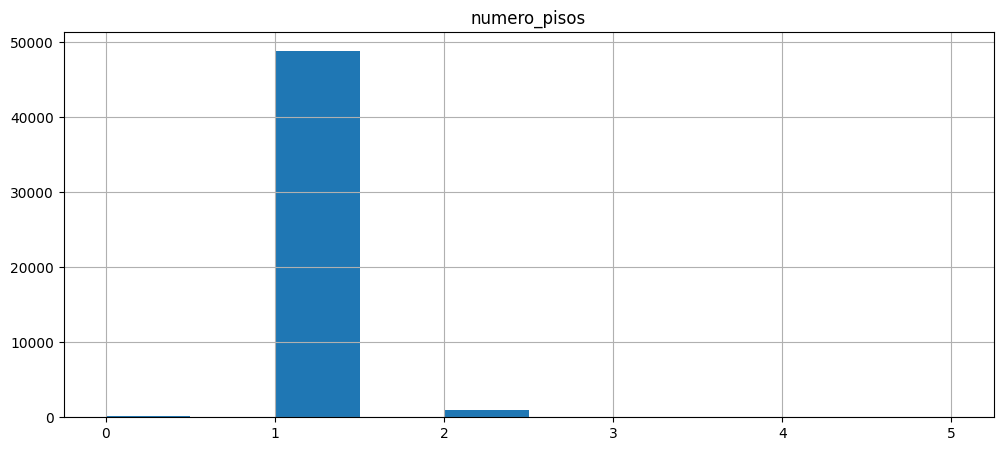

In [35]:

# Histograma de variables numéricas

df_modelo[['numero_pisos', 'area', 'perimetro']].hist(figsize=(12,5))

plt.show()


In [ ]:
# Departamentos con mayor cantidad de registros

df_modelo['departamento'].value_counts().head(15).plot(
    kind='bar',
    figsize=(12,5)
)

plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.title('Departamentos con mayor cantidad de registros')

plt.show()

In [36]:

# Promedio de pisos por estrato

df_modelo.groupby('estrato')['numero_pisos'].mean()


estrato
1    1.019631
2    1.019676
3    1.021551
4    1.166667
5    1.000000
6    1.000000
Name: numero_pisos, dtype: float64

In [39]:

# Área promedio por estrato

df_modelo.groupby('estrato')['area'].mean()


estrato
1     68.980078
2    412.408542
3     61.814149
4     29.743815
5     69.278320
6     41.714355
Name: area, dtype: float64

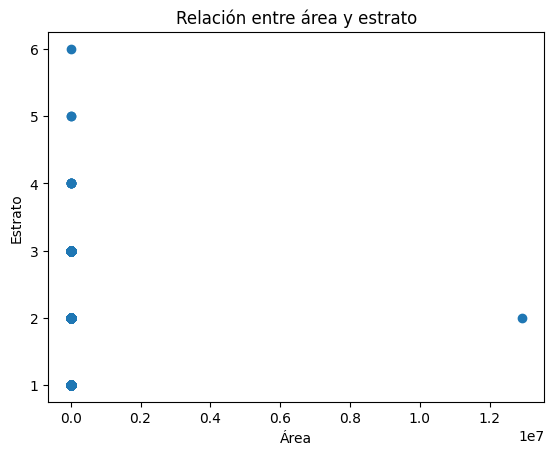

In [40]:

# Relación área vs estrato

plt.scatter(df_modelo['area'], df_modelo['estrato'])

plt.xlabel('Área')
plt.ylabel('Estrato')
plt.title('Relación entre área y estrato')

plt.show()



# 1.5 Revisión de calidad de datos

La calidad de datos es fundamental para garantizar resultados confiables durante el análisis.


In [41]:

# Valores faltantes

df_modelo.isnull().sum()


departamento              0
codigo_departamento       0
numero_pisos              0
area                      0
perimetro                 0
tipo_dominio           1094
tipo_construccion         0
estrato                   0
dtype: int64

In [ ]:
# Porcentaje de valores faltantes

(df_modelo.isnull().sum() / len(df_modelo)) * 100

In [ ]:
# Cantidad de valores únicos por variable

df_modelo.nunique()

In [42]:

# Registros duplicados

df_modelo.duplicated().sum()


np.int64(222)

In [43]:

# Tipos de datos

df_modelo.dtypes


departamento            object
codigo_departamento      int64
numero_pisos             int64
area                   float64
perimetro              float64
tipo_dominio            object
tipo_construccion       object
estrato                  int64
dtype: object

In [44]:

# Valores únicos de variables categóricas

print(df_modelo['tipo_dominio'].unique())
print(df_modelo['tipo_construccion'].unique())


['PRIVADO' nan 'COMUN']
['CONVENCIONAL' 'NO CONVENCIONAL']


# Hallazgos preliminares

- El proceso de integración permitió consolidar información territorial y catastral en un único dataset analítico.

- El dataset consolidado contiene 50.000 registros asociados a múltiples departamentos de Colombia.

- La variable estrato presenta una distribución desigual entre categorías socioeconómicas.

- Las variables área, perímetro y número de pisos muestran variabilidad significativa entre registros.

- La exploración inicial permitió identificar variables relevantes para el análisis descriptivo territorial.

- La revisión de calidad evidenció la necesidad de aplicar procesos posteriores de limpieza, transformación y agrupación de datos.

- La estructura del dataset permitió continuar con las fases Modify y Model de la metodología SEMMA.